# Sri Lanka Tourism Big Data Analytics and Recommendation System

## Big Data Analytics Mini Project

This notebook is the main assignment file. It contains the complete PySpark implementation for both parts of the mini project:

- **Part A:** Big Data analytics using Apache Spark
- **Part B:** Tourism recommendation system using Spark ML and review-text similarity

The project analyzes Sri Lankan tourism destination reviews, extracts useful analytics, and recommends destinations based on district preference, travel themes, sentiment quality, popularity, and TF-IDF content similarity.

## 1. Project Objectives

The objectives of this project are:

1. Load and clean a raw tourism review dataset using PySpark.
2. Analyze review volume, district demand, and sentiment distribution.
3. Create destination quality scores using sentiment, popularity, engagement, and theme diversity.
4. Build district-based and content-based tourism recommendations.
5. Generate charts and dashboard data for presentation/demo purposes.

## 2. Dataset Description

The dataset file is:

`data/Destination Reviews_(raw).csv`

Main columns:

- `Destination`: tourism location name
- `District`: district of the destination
- `Timespan`: when the review was posted
- `Review`: tourist review text

The raw review text contains noisy values, punctuation, encoding artifacts, commas, quotation marks, and multiline text. Therefore, Spark CSV loading and data cleaning are important parts of the project.

## 3. Import Libraries and Set Paths

This cell imports PySpark, Spark ML, plotting, and utility libraries. In a notebook, `__file__` is not available, so the project directory is set using `Path.cwd()`.

In [21]:
import json
import math
import os
import sys
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
from pyspark.ml.feature import HashingTF, IDF, StopWordsRemover, Tokenizer
from pyspark.sql import DataFrame, SparkSession, Window
from pyspark.sql.functions import (
    avg,
    col,
    concat_ws,
    count,
    countDistinct,
    desc,
    length,
    lit,
    lower,
    regexp_replace,
    round as spark_round,
    row_number,
    sum as spark_sum,
    trim,
    when,
)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "Destination Reviews_(raw).csv"
OUTPUT_DIR = PROJECT_DIR / "outputs"

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)

Project directory: c:\Users\DELL\Desktop\My_Repos\tourism-spark-project
Dataset path: c:\Users\DELL\Desktop\My_Repos\tourism-spark-project\data\Destination Reviews_(raw).csv


## 4. Configuration and Domain Rules

The dataset does not include labelled sentiment, destination categories, user IDs, or ratings. Because of that, this project uses transparent rule-based feature engineering:

- `VALID_DISTRICTS` is used to remove malformed district values.
- `POSITIVE_TERMS` and `NEGATIVE_TERMS` are used for simple lexicon-based sentiment scoring.
- `THEME_PATTERNS` is used to detect travel themes from review text.
- `RECENCY_PATTERNS` is used to group review timespan values.

These rules are easy to explain for the assignment. A future improvement would be to replace them with trained NLP models or labelled data.

In [22]:
VALID_DISTRICTS = [
    "Badulla", "Colombo", "Galle", "Gampaha", "Hambantota", "Hatton",
    "Kalmunai", "Kalutara", "Kurunagela", "Matale", "Matara", "Rathnapura",
]

POSITIVE_TERMS = [
    "amazing", "awesome", "beautiful", "best", "calm", "clean", "excellent",
    "fantastic", "good", "great", "love", "lovely", "peaceful", "perfect",
    "recommend", "scenic", "wonderful", "worth",
]

NEGATIVE_TERMS = [
    "bad", "boring", "crowded", "dirty", "disappointed", "expensive",
    "litter", "poor", "rude", "sad", "unsafe", "waste", "worst",
]

THEME_PATTERNS = {
    "Nature": r"\b(nature|green|forest|mountain|waterfall|lake|river|scenic|view|hike|trail|wildlife|bird|plain|ella)\b",
    "Beach": r"\b(beach|sea|ocean|sand|surf|coast|whale|boat|lagoon)\b",
    "Culture": r"\b(temple|kovil|church|fort|museum|heritage|history|historic|ancient|buddha|religious|palace)\b",
    "Family": r"\b(family|kids|children|park|picnic|play|garden|zoo|safari)\b",
    "Adventure": r"\b(hike|trek|climb|adventure|camp|cycling|surf|safari|trail|viewpoint)\b",
    "Relaxation": r"\b(calm|peaceful|relax|quiet|leisure|walk|beautiful|clean|evening)\b",
}

RECENCY_PATTERNS = {
    "Recent": r"\b(day|days|week|weeks|month|months)\s+ago\b",
    "Established": r"\b(year|years)\s+ago\b",
}

## 5. Start Spark Session

A Spark session is required for DataFrame processing, SQL-style aggregations, window functions, and Spark ML feature extraction.

In [23]:
def start_spark() -> SparkSession:
    os.environ["PYSPARK_PYTHON"] = sys.executable
    os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

    spark = (
        SparkSession.builder
        .appName("SriLankaTourismAnalyticsRecommendation")
        .config("spark.sql.shuffle.partitions", "8")
        .config("spark.pyspark.python", sys.executable)
        .config("spark.pyspark.driver.python", sys.executable)
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")
    return spark

spark = start_spark()
spark

## 6. Load Raw Dataset with Spark

The CSV is loaded with multiline, quote, escape, and encoding handling because review text can contain commas, quotation marks, and multiple lines.

In [24]:
raw_df = (
    spark.read.option("header", True)
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("encoding", "ISO-8859-1")
    .csv(str(DATA_PATH))
)

raw_df.printSchema()
raw_df.show(5, truncate=80)

root
 |-- Destination: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Timespan: string (nullable = true)
 |-- Review: string (nullable = true)

+-----------------------+--------+------------+--------------------------------------------------------------------------------+
|            Destination|District|    Timespan|                                                                          Review|
+-----------------------+--------+------------+--------------------------------------------------------------------------------+
|Attidiya Bird Sanctuary| Colombo|3 months ago|Some spots are very scenic and make it an ideal dwelling for birds and other ...|
|Attidiya Bird Sanctuary| Colombo|3 months ago|Good place for birdwatching not only waterbirds, different type of species ar...|
|Attidiya Bird Sanctuary| Colombo| 5 years ago|Calm and peaceful location to visit in your leisure time. They got a separate...|
|Attidiya Bird Sanctuary| Colombo| 3 years ago|This is one 

## 7. Data Cleaning and Preprocessing

Cleaning steps:

1. Keep only the required columns.
2. Remove rows with missing destination, district, or review values.
3. Keep only valid district names.
4. Remove very short reviews.
5. Convert review text to lowercase.
6. Remove punctuation and normalize extra spaces.

In [25]:
def clean_data(df: DataFrame) -> DataFrame:
    cleaned = (
        df.select(
            trim(col("Destination")).alias("Destination"),
            trim(col("District")).alias("District"),
            trim(col("Timespan")).alias("Timespan"),
            trim(col("Review")).alias("Review"),
        )
        .dropna(subset=["Destination", "District", "Review"])
        .filter(col("Destination") != "")
        .filter(col("District").isin(VALID_DISTRICTS))
        .filter(length(col("Review")) >= 10)
        .withColumn("review_lower", lower(col("Review")))
        .withColumn("review_clean", regexp_replace(col("review_lower"), r"[^a-z0-9\s]", " "))
        .withColumn("review_clean", regexp_replace(col("review_clean"), r"\s+", " "))
    )
    return cleaned

clean_df = clean_data(raw_df).cache()

print(f"Clean review rows: {clean_df.count():,}")
print(f"Destinations: {clean_df.select('Destination').distinct().count():,}")
print(f"Districts: {clean_df.select('District').distinct().count():,}")
clean_df.groupBy("District").count().orderBy(desc("count")).show(20, truncate=False)

Clean review rows: 35,509
Destinations: 236
Districts: 12
+----------+-----+
|District  |count|
+----------+-----+
|Matale    |5958 |
|Colombo   |5745 |
|Hatton    |4759 |
|Matara    |4423 |
|Kurunagela|2906 |
|Badulla   |2884 |
|Galle     |2654 |
|Hambantota|2287 |
|Rathnapura|1628 |
|Gampaha   |1531 |
|Kalutara  |617  |
|Kalmunai  |117  |
+----------+-----+



## 8. Feature Engineering

This section creates features used for analytics and recommendation:

- `sentiment_score`: positive keyword count minus negative keyword count
- `sentiment`: Positive, Neutral, or Negative
- `word_count`: review engagement signal
- `recency_segment`: Recent, Established, or Unknown
- `travel_theme`: Nature, Beach, Culture, Family, Adventure, Relaxation, or General

In [26]:
def term_score(column_name: str, terms: list[str]):
    score = None
    for term in terms:
        hit = when(col(column_name).rlike(rf"\b{term}\b"), 1).otherwise(0)
        score = hit if score is None else score + hit
    return score


def add_sentiment(df: DataFrame) -> DataFrame:
    return (
        df.withColumn("positive_score", term_score("review_clean", POSITIVE_TERMS))
        .withColumn("negative_score", term_score("review_clean", NEGATIVE_TERMS))
        .withColumn("sentiment_score", col("positive_score") - col("negative_score"))
        .withColumn(
            "sentiment",
            when(col("sentiment_score") > 0, "Positive")
            .when(col("sentiment_score") < 0, "Negative")
            .otherwise("Neutral"),
        )
    )


def add_experience_features(df: DataFrame) -> DataFrame:
    featured = df.withColumn(
        "word_count",
        length(col("review_clean")) - length(regexp_replace(col("review_clean"), " ", "")) + 1,
    )

    featured = featured.withColumn(
        "recency_segment",
        when(lower(col("Timespan")).rlike(RECENCY_PATTERNS["Recent"]), "Recent")
        .when(lower(col("Timespan")).rlike(RECENCY_PATTERNS["Established"]), "Established")
        .otherwise("Unknown"),
    )

    theme_expr = lit("General")
    for theme, pattern in reversed(THEME_PATTERNS.items()):
        theme_expr = when(col("review_clean").rlike(pattern), lit(theme)).otherwise(theme_expr)

    return featured.withColumn("travel_theme", theme_expr)

reviews_df = add_experience_features(add_sentiment(clean_df)).cache()
reviews_df.select("Destination", "District", "sentiment", "word_count", "recency_segment", "travel_theme").show(10, truncate=False)

+-----------------------+--------+---------+----------+---------------+------------+
|Destination            |District|sentiment|word_count|recency_segment|travel_theme|
+-----------------------+--------+---------+----------+---------------+------------+
|Attidiya Bird Sanctuary|Colombo |Positive |36        |Recent         |Nature      |
|Attidiya Bird Sanctuary|Colombo |Positive |13        |Recent         |General     |
|Attidiya Bird Sanctuary|Colombo |Positive |44        |Established    |Family      |
|Attidiya Bird Sanctuary|Colombo |Neutral  |45        |Established    |General     |
|Attidiya Bird Sanctuary|Colombo |Neutral  |43        |Established    |Nature      |
|Attidiya Bird Sanctuary|Colombo |Positive |28        |Established    |Adventure   |
|Attidiya Bird Sanctuary|Colombo |Neutral  |42        |Established    |Family      |
|Attidiya Bird Sanctuary|Colombo |Neutral  |46        |Established    |General     |
|Attidiya Bird Sanctuary|Colombo |Positive |43        |Establishe

# Part A: Big Data Analytics Using Spark

The following cells answer the analytics part of the assignment using Spark DataFrame transformations, aggregations, and window functions.

## 9. Top Destinations by Review Volume

This shows which destinations have the most tourist review activity.

In [27]:
top_destinations = (
    reviews_df.groupBy("Destination", "District")
    .count()
    .orderBy(desc("count"))
)

top_destinations.show(10, truncate=False)

+----------------------------+----------+-----+
|Destination                 |District  |count|
+----------------------------+----------+-----+
|Horton plains national park |Hatton    |1038 |
|Riverston                   |Matale    |911  |
|Moon plains                 |Hatton    |764  |
|Bambarakiri ella            |Matale    |757  |
|Kurunagela clock tower      |Kurunagela|742  |
|Sembuwatta lake             |Matale    |664  |
|Yapahuwa rock fortress      |Kurunagela|663  |
|Pitawala pathana , riverston|Matale    |613  |
|Sera ella water falls       |Matale    |529  |
|Sri muththumari amman kovil |Matale    |528  |
+----------------------------+----------+-----+
only showing top 10 rows


## 10. Overall Sentiment Distribution

This shows whether tourist comments are generally positive, neutral, or negative.

In [28]:
sentiment_summary = (
    reviews_df.groupBy("sentiment")
    .count()
    .withColumn("percentage", spark_round(col("count") / reviews_df.count() * 100, 2))
    .orderBy(desc("count"))
)

sentiment_summary.show(truncate=False)

+---------+-----+----------+
|sentiment|count|percentage|
+---------+-----+----------+
|Positive |18951|53.37     |
|Neutral  |15903|44.79     |
|Negative |655  |1.84      |
+---------+-----+----------+



## 11. Destination Quality Ranking

The destination recommendation score combines four signals:

- Bayesian positive sentiment rate: reduces over-ranking of very small samples
- Popularity score: review-volume confidence
- Engagement score: average review detail/length
- Theme diversity: variety of experience categories

In [29]:
global_positive_rate = reviews_df.agg(
    avg(when(col("sentiment") == "Positive", 1.0).otherwise(0.0))
).first()[0]
prior_strength = 50

destination_quality = (
    reviews_df.groupBy("Destination", "District")
    .agg(
        count("*").alias("review_count"),
        spark_sum(when(col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews"),
        spark_sum(when(col("sentiment") == "Negative", 1).otherwise(0)).alias("negative_reviews"),
        avg("sentiment_score").alias("avg_sentiment_score"),
        avg("word_count").alias("avg_review_words"),
        countDistinct("travel_theme").alias("theme_diversity"),
    )
    .withColumn("positive_rate", spark_round(col("positive_reviews") / col("review_count"), 3))
    .withColumn(
        "bayesian_positive_rate",
        spark_round(
            (col("positive_reviews") + lit(global_positive_rate * prior_strength))
            / (col("review_count") + lit(prior_strength)),
            3,
        ),
    )
    .withColumn("popularity_score", spark_round(col("review_count") / (col("review_count") + lit(120)), 3))
    .withColumn(
        "engagement_score",
        spark_round(when(col("avg_review_words") >= 55, 1.0).otherwise(col("avg_review_words") / 55), 3),
    )
    .withColumn(
        "recommendation_score",
        spark_round(
            (col("bayesian_positive_rate") * 0.48)
            + (col("popularity_score") * 0.27)
            + (col("engagement_score") * 0.15)
            + (when(col("theme_diversity") >= 3, 1.0).otherwise(col("theme_diversity") / 3) * 0.10),
            3,
        ),
    )
    .orderBy(desc("recommendation_score"), desc("review_count"))
).cache()

destination_quality.show(10, truncate=False)

+--------------------------------------+--------+------------+----------------+----------------+-------------------+------------------+---------------+-------------+----------------------+----------------+----------------+--------------------+
|Destination                           |District|review_count|positive_reviews|negative_reviews|avg_sentiment_score|avg_review_words  |theme_diversity|positive_rate|bayesian_positive_rate|popularity_score|engagement_score|recommendation_score|
+--------------------------------------+--------+------------+----------------+----------------+-------------------+------------------+---------------+-------------+----------------------+----------------+----------------+--------------------+
|Raja & the Whales                     |Matara  |268         |205             |2               |1.1194029850746268 |33.39179104477612 |5              |0.765        |0.729                 |0.691           |0.607           |0.728               |
|Horton plains national 

## 12. District-Level Recommendations and Insights

Spark window functions are used to rank the top three destinations inside each district.

In [30]:
district_window = Window.partitionBy("District").orderBy(desc("recommendation_score"), desc("review_count"))

best_by_district = (
    destination_quality.withColumn("rank", row_number().over(district_window))
    .filter(col("rank") <= 3)
    .orderBy("District", "rank")
).cache()

best_by_district.show(40, truncate=False)

district_insights = (
    reviews_df.groupBy("District")
    .agg(
        count("*").alias("review_count"),
        countDistinct("Destination").alias("destination_count"),
        spark_sum(when(col("sentiment") == "Positive", 1).otherwise(0)).alias("positive_reviews"),
        spark_sum(when(col("sentiment") == "Negative", 1).otherwise(0)).alias("negative_reviews"),
        avg("sentiment_score").alias("avg_sentiment_score"),
    )
    .withColumn("positive_rate", spark_round(col("positive_reviews") / col("review_count"), 3))
    .withColumn("reviews_per_destination", spark_round(col("review_count") / col("destination_count"), 1))
    .withColumn(
        "opportunity_score",
        spark_round(
            (col("positive_rate") * 0.55)
            + ((lit(1) - (col("reviews_per_destination") / (col("reviews_per_destination") + lit(160)))) * 0.45),
            3,
        ),
    )
    .orderBy(desc("review_count"))
).cache()

district_insights.show(20, truncate=False)

+------------------------------------+----------+------------+----------------+----------------+-------------------+------------------+---------------+-------------+----------------------+----------------+----------------+--------------------+----+
|Destination                         |District  |review_count|positive_reviews|negative_reviews|avg_sentiment_score|avg_review_words  |theme_diversity|positive_rate|bayesian_positive_rate|popularity_score|engagement_score|recommendation_score|rank|
+------------------------------------+----------+------------+----------------+----------------+-------------------+------------------+---------------+-------------+----------------------+----------------+----------------+--------------------+----+
|Diyaluma Falls                      |Badulla   |269         |174             |1               |0.8996282527881041 |33.94423791821561 |5              |0.647        |0.629                 |0.692           |0.617           |0.681               |1   |
|Bom

## 13. Theme-Based Tourism Hotspots

This analysis ranks destinations within each travel theme. Bayesian smoothing is used so that destinations with only a few positive theme reviews do not rank unfairly high.

In [31]:
category_hotspots = (
    reviews_df.groupBy("travel_theme", "Destination", "District")
    .agg(
        count("*").alias("theme_reviews"),
        spark_sum(when(col("sentiment") == "Positive", 1).otherwise(0)).alias("theme_positive_reviews"),
        avg(when(col("sentiment") == "Positive", 1.0).otherwise(0.0)).alias("theme_positive_rate"),
    )
    .withColumn(
        "theme_bayesian_positive_rate",
        (col("theme_positive_reviews") + lit(global_positive_rate * 25)) / (col("theme_reviews") + lit(25)),
    )
    .withColumn(
        "theme_score",
        spark_round(
            (col("theme_bayesian_positive_rate") * 0.7)
            + (col("theme_reviews") / (col("theme_reviews") + lit(80)) * 0.3),
            3,
        ),
    )
)

theme_window = Window.partitionBy("travel_theme").orderBy(desc("theme_score"), desc("theme_reviews"))
category_hotspots = (
    category_hotspots.withColumn("rank", row_number().over(theme_window))
    .filter(col("rank") <= 5)
    .orderBy("travel_theme", "rank")
).cache()

category_hotspots.show(50, truncate=False)

+------------+--------------------------------------+----------+-------------+----------------------+-------------------+----------------------------+-----------+----+
|travel_theme|Destination                           |District  |theme_reviews|theme_positive_reviews|theme_positive_rate|theme_bayesian_positive_rate|theme_score|rank|
+------------+--------------------------------------+----------+-------------+----------------------+-------------------+----------------------------+-----------+----+
|Adventure   |Horton plains national park           |Hatton    |30           |25                    |0.8333333333333334 |0.6971344012657482          |0.57       |1   |
|Adventure   |Parrot Rock                           |Matara    |11           |11                    |1.0                |0.6761775574893376          |0.51       |2   |
|Adventure   |Riverston                             |Matale    |14           |12                    |0.8571428571428571 |0.6498049248619526          |0.5       

# Part B: Recommendation System

This section builds the recommendation system required by the assignment.

The project includes:

1. **District-based recommendation:** ranks destinations within a selected district.
2. **Content-based recommendation:** uses Spark ML TF-IDF destination profiles and cosine similarity.
3. **Hybrid ranking:** combines text similarity with sentiment and popularity confidence.

## 14. District-Based Recommendation Function

The user selects a district, and the system returns the strongest destinations in that district.

In [32]:
def recommend_by_district(destination_quality_df: DataFrame, district: str, top_n: int = 5) -> DataFrame:
    return (
        destination_quality_df.filter(lower(col("District")) == district.lower())
        .select(
            "Destination",
            "District",
            "review_count",
            "positive_reviews",
            "negative_reviews",
            "positive_rate",
            "recommendation_score",
        )
        .orderBy(desc("recommendation_score"), desc("review_count"))
        .limit(top_n)
    )

recommend_by_district(destination_quality, "Colombo").show(truncate=False)

+----------------------+--------+------------+----------------+----------------+-------------+--------------------+
|Destination           |District|review_count|positive_reviews|negative_reviews|positive_rate|recommendation_score|
+----------------------+--------+------------+----------------+----------------+-------------+--------------------+
|Beddagana Wetland Park|Colombo |200         |155             |4               |0.775        |0.713               |
|Diyatha Uyana         |Colombo |200         |136             |2               |0.68         |0.673               |
|Mount Lavania Beach   |Colombo |200         |140             |10              |0.7          |0.663               |
|Viharamahadevi Park   |Colombo |210         |130             |3               |0.619        |0.642               |
|Gangarama Sima Malaka |Colombo |199         |122             |2               |0.613        |0.631               |
+----------------------+--------+------------+----------------+---------

## 15. Content-Based Recommendation Using Spark ML TF-IDF

For content-based recommendation, all reviews for each destination are combined into one destination profile. Spark ML is then used to convert review text into TF-IDF feature vectors.

In [33]:
def build_destination_profiles(df: DataFrame) -> DataFrame:
    profiles = df.groupBy("Destination", "District").agg(
        concat_ws(" ", collect_list(col("Review"))).alias("all_reviews"),
        count("*").alias("review_count"),
        avg("sentiment_score").alias("avg_sentiment_score"),
    )

    tokenizer = Tokenizer(inputCol="all_reviews", outputCol="tokens")
    tokenized = tokenizer.transform(profiles)

    remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
    filtered = remover.transform(tokenized)

    hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="raw_features", numFeatures=2048)
    featurized = hashing_tf.transform(filtered)

    idf = IDF(inputCol="raw_features", outputCol="features")
    return idf.fit(featurized).transform(featurized)

# collect_list is imported here to keep the TF-IDF section clear.
from pyspark.sql.functions import collect_list

profiles = build_destination_profiles(reviews_df).cache()
profiles.select("Destination", "District", "review_count", "avg_sentiment_score").show(10, truncate=False)

+----------------------------+----------+------------+-------------------+
|Destination                 |District  |review_count|avg_sentiment_score|
+----------------------------+----------+------------+-------------------+
|Badulla Katharagama Devalaya|Badulla   |48          |0.1875             |
|Biso Ella Waterfall         |Matara    |49          |0.6530612244897959 |
|Bomburu Ella Waterfall      |Badulla   |232         |0.8189655172413793 |
|Coconut Tree Hill           |Matara    |280         |0.9571428571428572 |
|Delgamuwa Rajamaha Viharaya |Rathnapura|72          |0.3333333333333333 |
|Dumbara ella waterfalls     |Matale    |70          |0.6285714285714286 |
|Dutch Reformed Church       |Galle     |122         |0.4344262295081967 |
|Guruge Park                 |Gampaha   |220         |0.6045454545454545 |
|Hamilton Canal Park         |Colombo   |59          |0.6101694915254238 |
|Kelaniya Raja Maha Viharaya |Colombo   |197         |0.43147208121827413|
+------------------------

## 16. Cosine Similarity and Hybrid Recommendation

Cosine similarity finds destinations with similar TF-IDF review profiles. The final hybrid score also considers sentiment quality and popularity confidence.

In [34]:
def cosine_similarity(a, b) -> float:
    if a is None or b is None:
        return 0.0
    norm_product = math.sqrt(float(a.dot(a))) * math.sqrt(float(b.dot(b)))
    if norm_product == 0:
        return 0.0
    return float(a.dot(b)) / norm_product


def recommend_similar_destinations(profiles_df: DataFrame, liked_destination: str, top_n: int = 5):
    rows = profiles_df.select(
        "Destination", "District", "review_count", "avg_sentiment_score", "features"
    ).collect()

    liked_row = next(
        (row for row in rows if row["Destination"].lower() == liked_destination.lower()),
        None,
    )
    if liked_row is None:
        raise ValueError(f"Destination not found: {liked_destination}")

    recommendations = []
    for row in rows:
        if row["Destination"].lower() == liked_destination.lower():
            continue

        similarity = cosine_similarity(row["features"], liked_row["features"])
        popularity = int(row["review_count"]) / (int(row["review_count"]) + 120)
        sentiment_signal = max(min((float(row["avg_sentiment_score"]) + 2) / 4, 1), 0)
        hybrid_score = (similarity * 0.60) + (sentiment_signal * 0.25) + (popularity * 0.15)

        recommendations.append(
            (
                row["Destination"],
                row["District"],
                int(row["review_count"]),
                round(float(row["avg_sentiment_score"]), 3),
                round(similarity, 3),
                round(hybrid_score, 3),
            )
        )

    return sorted(recommendations, key=lambda item: (item[5], item[4], item[2]), reverse=True)[:top_n]

similar_to_riverston = recommend_similar_destinations(profiles, "Riverston", top_n=5)
similar_to_riverston

[('Pitawala pathana , riverston', 'Matale', 613, 0.677, 0.589, 0.646),
 ('Horton plains national park', 'Hatton', 1038, 0.848, 0.409, 0.558),
 ('Sembuwatta lake', 'Matale', 664, 0.824, 0.421, 0.556),
 ('Bambarakiri ella', 'Matale', 757, 0.68, 0.429, 0.554),
 ("Hulangala mini world's end view", 'Matale', 231, 0.632, 0.449, 0.533)]

## 17. Recommendation Evaluation and Limitations

Since the dataset does not contain user IDs or explicit ratings, collaborative filtering cannot be fully applied. The recommender is evaluated using practical checks:

- Recommendation coverage: number of destination profiles available for recommendation
- Interpretability: recommendations similar to Riverston should be nature/scenic/mountain-like destinations
- Ranking quality: hybrid score combines text similarity, sentiment quality, and popularity confidence

Limitations:

- Sentiment and theme detection are rule-based.
- Sarcasm and complex mixed opinions may not be detected.
- Collaborative filtering would require user IDs and ratings.

In [35]:
coverage = profiles.select("Destination").distinct().count()
print(f"Recommendation coverage: {coverage} destination profiles")
print("Sample recommendations similar to Riverston:")
for rank, row in enumerate(similar_to_riverston, start=1):
    print(f"{rank}. {row[0]} ({row[1]}) - similarity={row[4]}, hybrid_score={row[5]}")

Recommendation coverage: 236 destination profiles
Sample recommendations similar to Riverston:
1. Pitawala pathana , riverston (Matale) - similarity=0.589, hybrid_score=0.646
2. Horton plains national park (Hatton) - similarity=0.409, hybrid_score=0.558
3. Sembuwatta lake (Matale) - similarity=0.421, hybrid_score=0.556
4. Bambarakiri ella (Matale) - similarity=0.429, hybrid_score=0.554
5. Hulangala mini world's end view (Matale) - similarity=0.449, hybrid_score=0.533


## 18. Visualizations

These charts are displayed inside the notebook and also saved into the `outputs` folder for the dashboard and presentation.


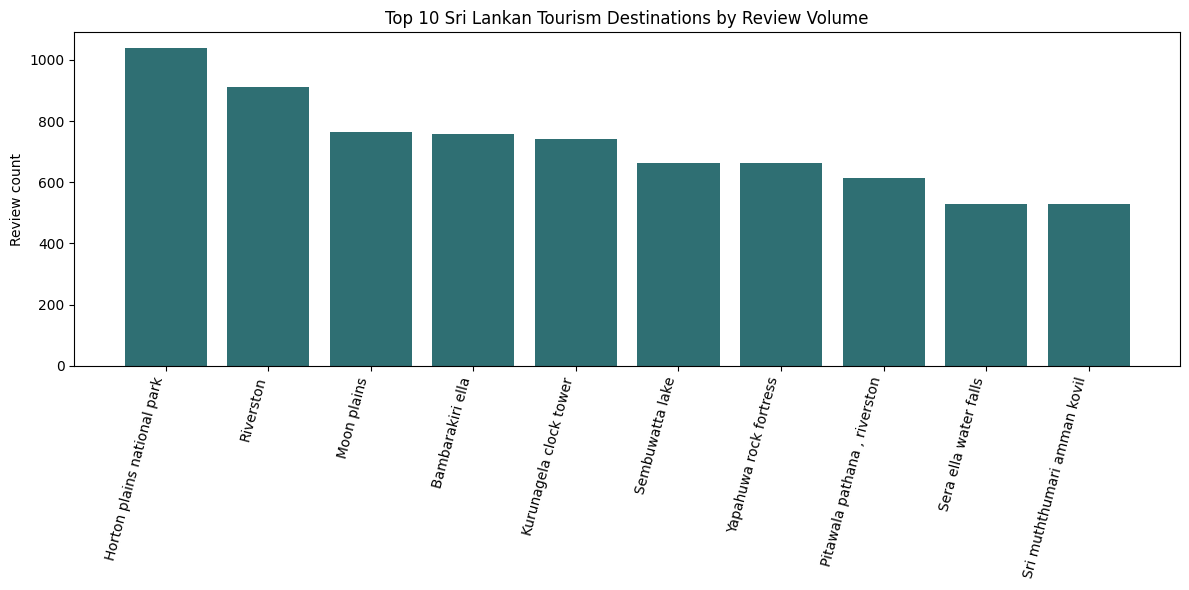

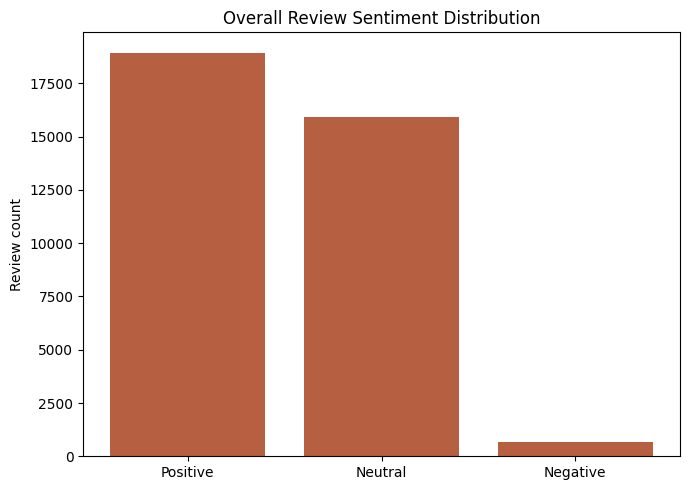

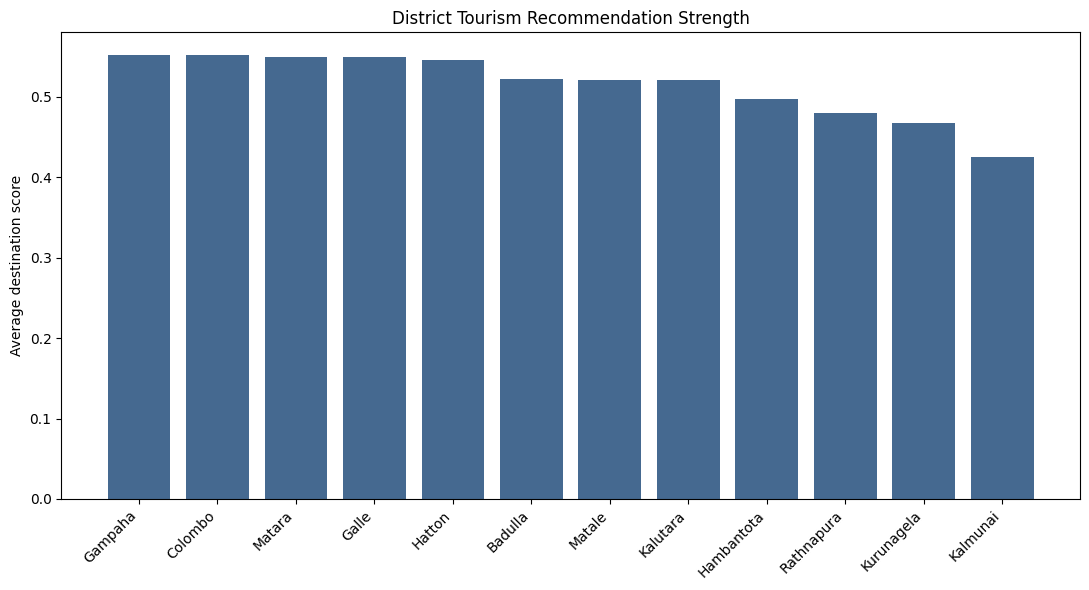

In [36]:
OUTPUT_DIR.mkdir(exist_ok=True)

# Chart 1: Top destinations by review volume
top_pd = destination_quality.orderBy(desc("review_count")).limit(10).toPandas()
plt.figure(figsize=(12, 6))
plt.bar(top_pd["Destination"], top_pd["review_count"], color="#2f6f73")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Review count")
plt.title("Top 10 Sri Lankan Tourism Destinations by Review Volume")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_destinations_latest.png", dpi=160)
plt.show()

# Chart 2: Sentiment distribution
sentiment_pd = sentiment_summary.toPandas()
plt.figure(figsize=(7, 5))
plt.bar(sentiment_pd["sentiment"], sentiment_pd["count"], color="#b65f41")
plt.ylabel("Review count")
plt.title("Overall Review Sentiment Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_distribution_latest.png", dpi=160)
plt.show()

# Chart 3: District recommendation strength
district_pd = destination_quality.groupBy("District").agg(
    avg("recommendation_score").alias("avg_score")
).orderBy(desc("avg_score")).toPandas()
plt.figure(figsize=(11, 6))
plt.bar(district_pd["District"], district_pd["avg_score"], color="#456990")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average destination score")
plt.title("District Tourism Recommendation Strength")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "district_strength.png", dpi=160)
plt.show()

## 19. Save Dashboard Data

This JSON file is used by `demo_ui.html` to display the dashboard tables and recommendations.


In [37]:
payload = {
    "top_destinations": destination_quality.orderBy(desc("review_count")).limit(10).toPandas().to_dict("records"),
    "best_by_district": best_by_district.toPandas().to_dict("records"),
    "district_insights": district_insights.toPandas().to_dict("records"),
    "category_hotspots": category_hotspots.toPandas().to_dict("records"),
    "similar_to_riverston": [
        {
            "Destination": row[0],
            "District": row[1],
            "review_count": row[2],
            "avg_sentiment_score": row[3],
            "similarity": row[4],
            "hybrid_score": row[5],
        }
        for row in recommend_similar_destinations(profiles, "Riverston", top_n=7)
    ],
}

with open(OUTPUT_DIR / "dashboard_data.json", "w", encoding="utf-8") as file:
    json.dump(payload, file, indent=2)

print("Charts and dashboard data saved to:", OUTPUT_DIR)

Charts and dashboard data saved to: c:\Users\DELL\Desktop\My_Repos\tourism-spark-project\outputs


## 20. Stop Spark Session

Run this after finishing the notebook to close the Spark session.

In [38]:
spark.stop()

## 21. Conclusion

This notebook demonstrates a complete Big Data Analytics workflow using Apache Spark:

- Raw CSV loading with Spark
- Data cleaning and text preprocessing
- Sentiment and theme feature engineering
- Destination, district, and theme analytics
- District-based recommendation
- Spark ML TF-IDF content-based recommendation
- Hybrid recommendation scoring
- Dashboard output generation

The project satisfies both the analytics and recommendation requirements of the mini project assignment.